In [ ]:
import pennylane as qml
from pennylane import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from pennylane.templates import AngleEmbedding, StronglyEntanglingLayers
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv("/Users//Downloads/diabetes_prediction_dataset.csv")
df.shape

(100000, 9)

In [ ]:
df = df.sample(n=5000, random_state=42)

In [ ]:
df.shape

(5000, 9)

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

In [ ]:
numeric_cols, categorical_cols

(Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
        'blood_glucose_level', 'diabetes'],
       dtype='object'),
 Index(['gender', 'smoking_history'], dtype='object'))

In [ ]:
# Encoding categorical variables using LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

<Axes: >

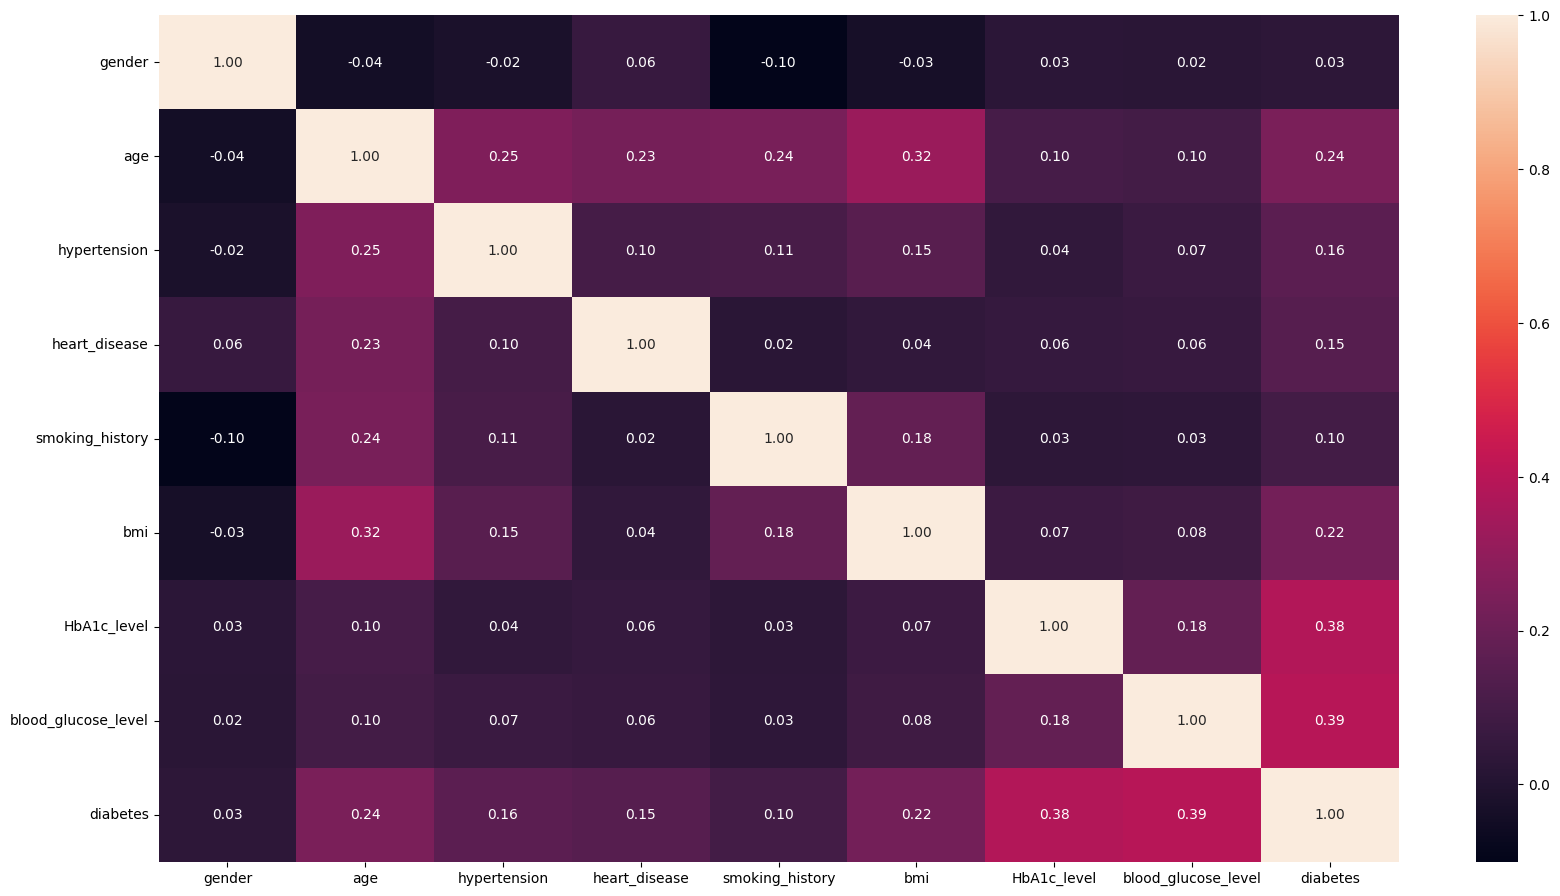

In [ ]:
corr=df.corr()
f, ax = plt.subplots(figsize=(20, 11))
sns.heatmap(corr,annot=True,fmt=".2f")

In [ ]:
df.drop(columns=['gender'],inplace=True)

In [ ]:
df.shape

(5000, 8)

In [ ]:
target = 'diabetes'
features = df.drop(columns=[target])
y = df[target].astype(int)  # Ensure target labels are integers for classification

In [ ]:
features.shape,y.shape

((5000, 7), (5000,))

In [ ]:
# Initialize the MinMaxScaler to scale features between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))

X = features
X_normalized = scaler.fit_transform(X)

# Convert the normalized data back to a DataFrame for better readability
features = pd.DataFrame(X_normalized, columns=X.columns)

# Display the first few rows to confirm the normalization
features.shape

(5000, 7)

In [ ]:
from imblearn.over_sampling import SMOTE
X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(features, y)

In [ ]:
X_resampled.shape

(9236, 7)

In [ ]:
pca = PCA(n_components=6)
pca.fit(X_resampled)
reduced_data = pca.transform(X_resampled)
print(sum(pca.explained_variance_ratio_))

0.9880295097891328


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(reduced_data, y_resampled, test_size=0.2, random_state=42)

In [ ]:
x_train.shape, y_train.shape

((7388, 6), (7388,))

Classical SVM

In [ ]:
svm =SVC(kernel='rbf').fit(x_train, y_train)
y_pred=svm.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8971861471861472

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.89       903
           1       0.89      0.91      0.90       945

    accuracy                           0.90      1848
   macro avg       0.90      0.90      0.90      1848
weighted avg       0.90      0.90      0.90      1848



QSVM

In [ ]:
# Define quantum device for QSVM
n_qubits = x_train.shape[1]
dev = qml.device('default.qubit', wires=n_qubits)

In [ ]:
n_qubits

6

In [ ]:
dev_kernel = qml.device("lightning.qubit", wires=n_qubits)

projector = np.zeros((2 ** n_qubits, 2 ** n_qubits))
projector[0, 0] = 1

@qml.qnode(dev_kernel)
def kernel(x1, x2):
    """The quantum kernel."""
    AngleEmbedding(x1, wires=range(n_qubits))
    qml.adjoint(AngleEmbedding)(x2, wires=range(n_qubits))
    return qml.expval(qml.Hermitian(projector, wires=range(n_qubits)))

In [ ]:
def kernel_matrix(A, B):
    """Compute the matrix whose entries are the kernel
       evaluated on pairwise data from sets A and B."""
    return np.array([[kernel(a, b) for b in B] for a in A])

In [ ]:
qsvm = SVC(kernel=kernel_matrix).fit(x_train, y_train)

In [ ]:
# Evaluate the model
y_pred=qsvm.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8521358159912377

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.82      0.85       925
           1       0.83      0.88      0.86       901

    accuracy                           0.85      1826
   macro avg       0.85      0.85      0.85      1826
weighted avg       0.85      0.85      0.85      1826



Saving Model

In [ ]:
import pickle

with open('classical_svm.pkl', 'wb') as f:
    pickle.dump(svm, f)

In [ ]:
with open('quantum_svm.pkl', 'wb') as f:
    pickle.dump(qsvm, f)

In [ ]:
#In another tab
import pickle
with open('classical_svm.pkl', 'rb') as f:
    model = pickle.load(f)

In [ ]:
#In another tab
import pickle
with open('quantum_svm.pkl', 'rb') as f:
    model = pickle.load(f)